In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("hospital_readmissions_30k.csv")

In [ ]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [ ]:
df.isnull().sum()

,0
patient_id,0
age,0
gender,0
blood_pressure,0
cholesterol,0
bmi,0
diabetes,0
hypertension,0
medication_count,0
length_of_stay,0


In [ ]:
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [ ]:
col=df.columns

In [ ]:
col

Index(['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi',
       'diabetes', 'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days'],
      dtype='object')

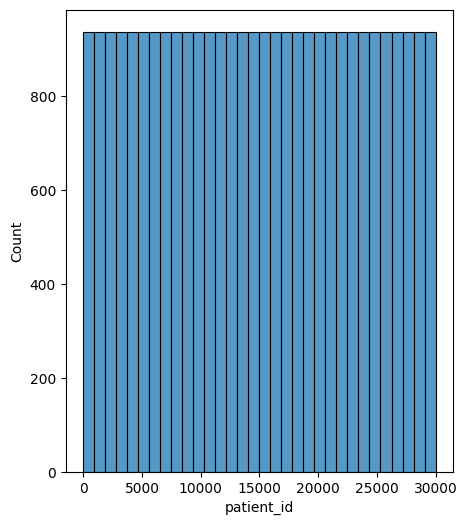

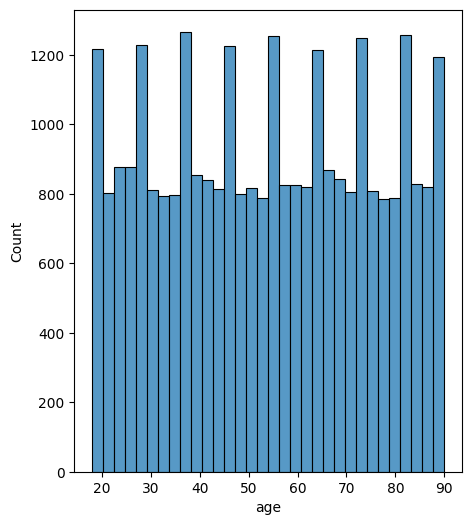

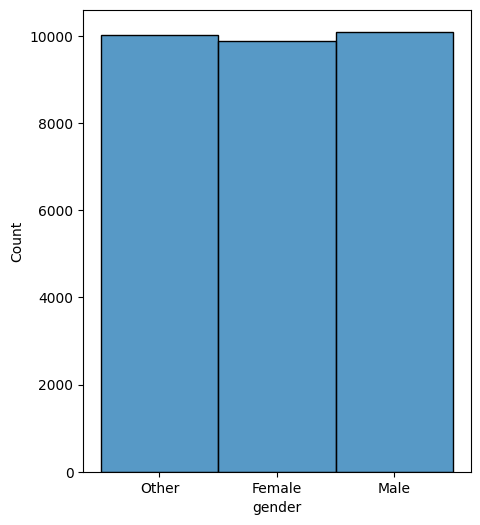

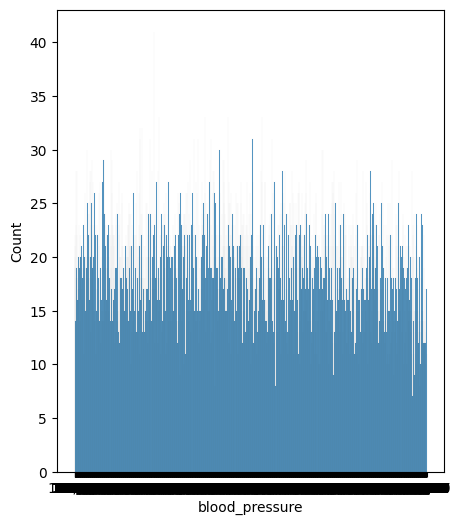

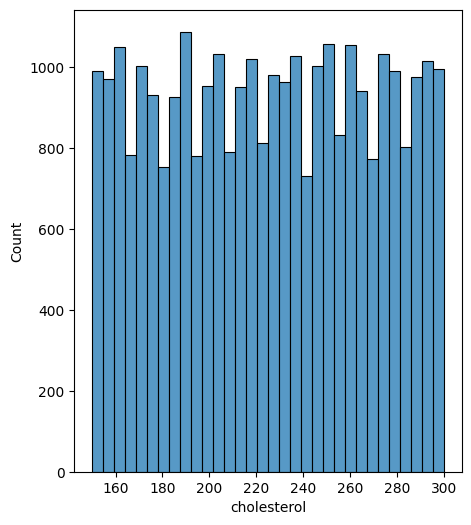

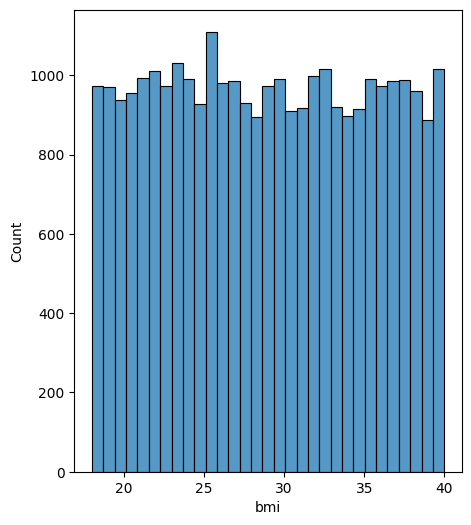

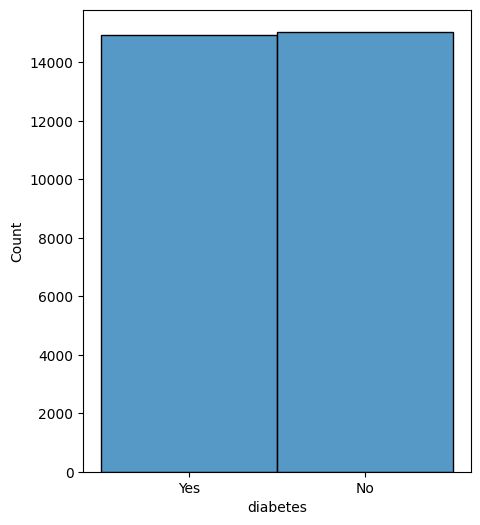

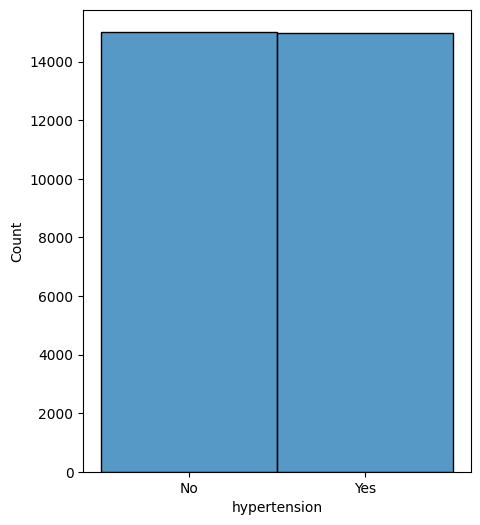

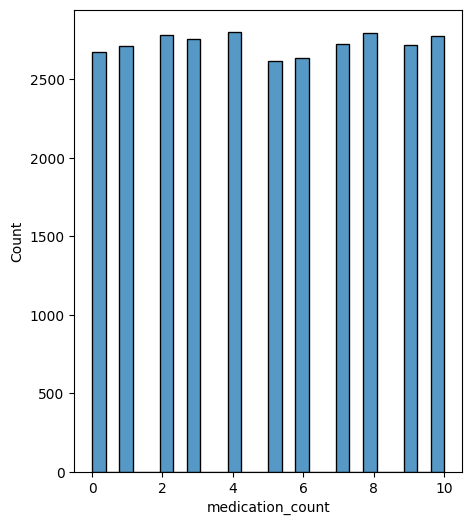

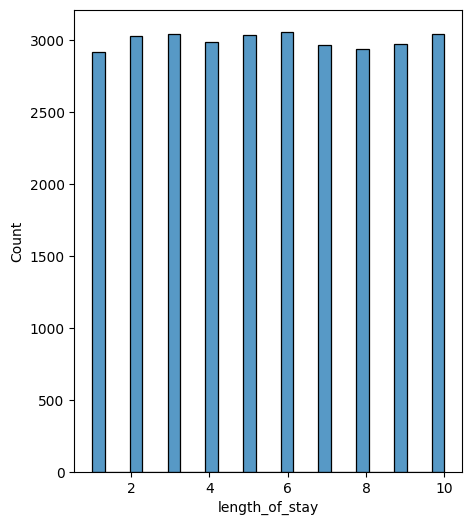

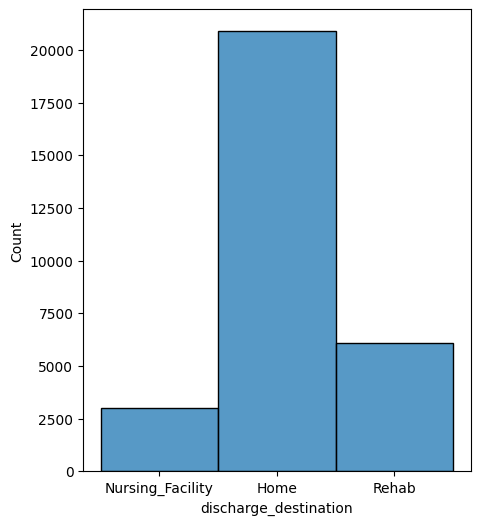

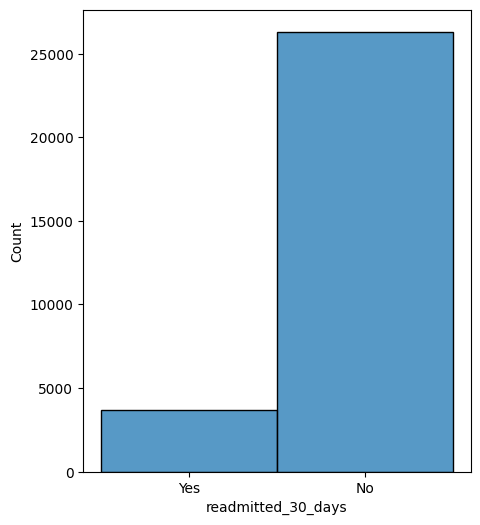

In [ ]:
for g in col:
  plt.figure(figsize=(5,6))
  sns.histplot(df[g])

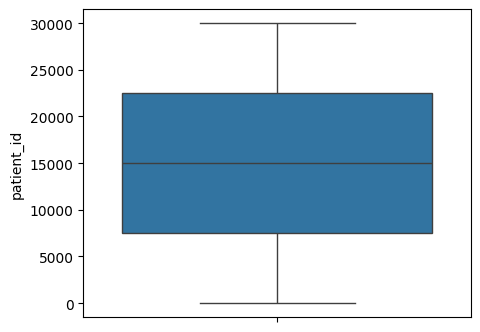

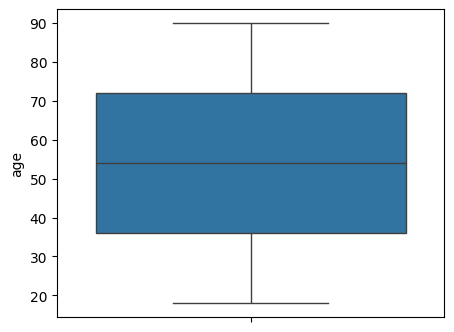

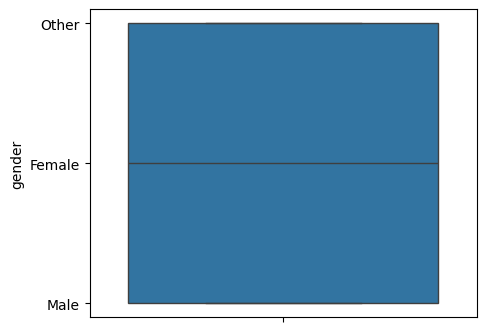

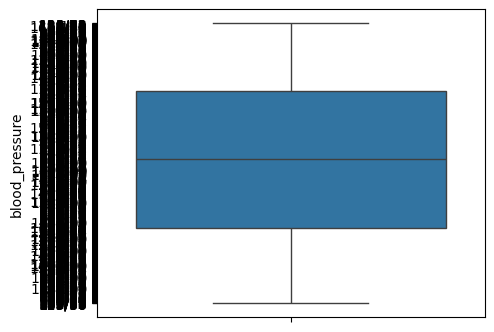

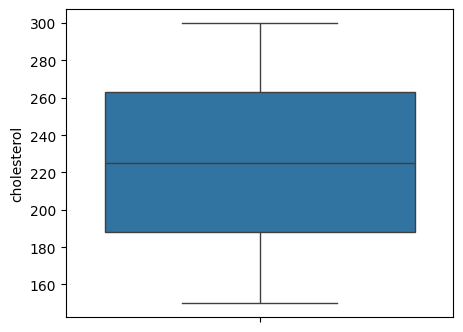

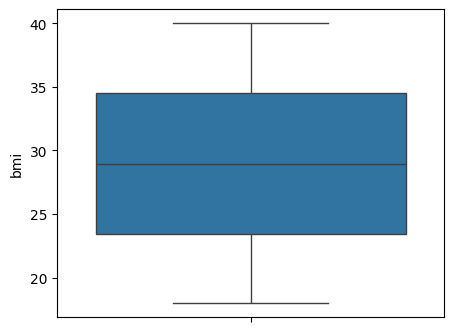

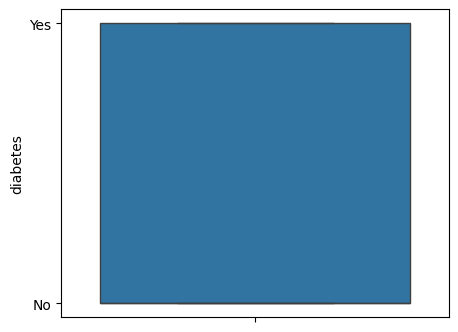

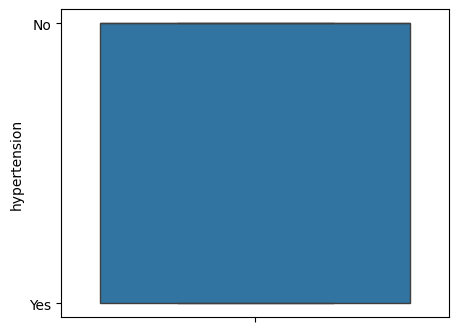

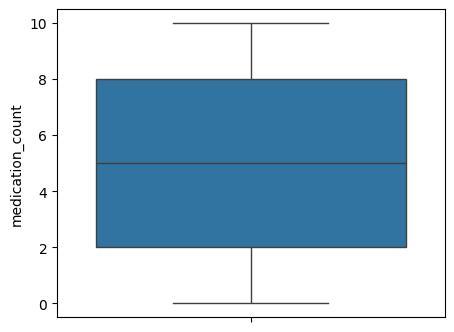

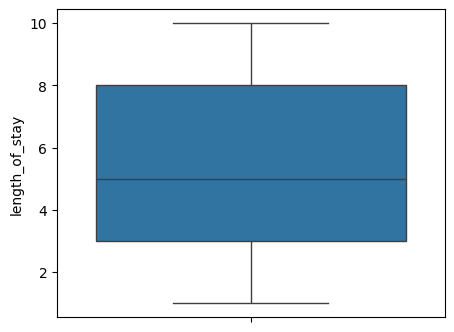

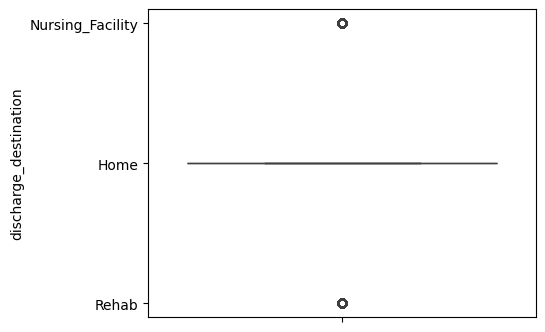

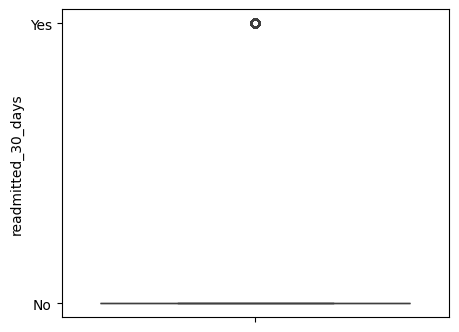

In [ ]:
for g in col:
  plt.figure(figsize=(5,4))
  sns.boxplot(df[g])

In [ ]:
df['readmitted_30_days'].value_counts()

,count
readmitted_30_days,
No,26326
Yes,3674


In [ ]:
df['readmitted_30_days']=df['readmitted_30_days'].map({'No':0,'Yes':1})

In [ ]:
df

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,1
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,0
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,0
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,0
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,112/80,157,31.4,No,No,4,10,Home,1
29996,29997,20,Other,146/83,198,30.2,No,Yes,4,1,Home,1
29997,29998,40,Other,131/96,275,23.3,Yes,Yes,7,2,Home,0
29998,29999,61,Other,124/75,232,34.3,No,No,5,3,Home,0


<Axes: >

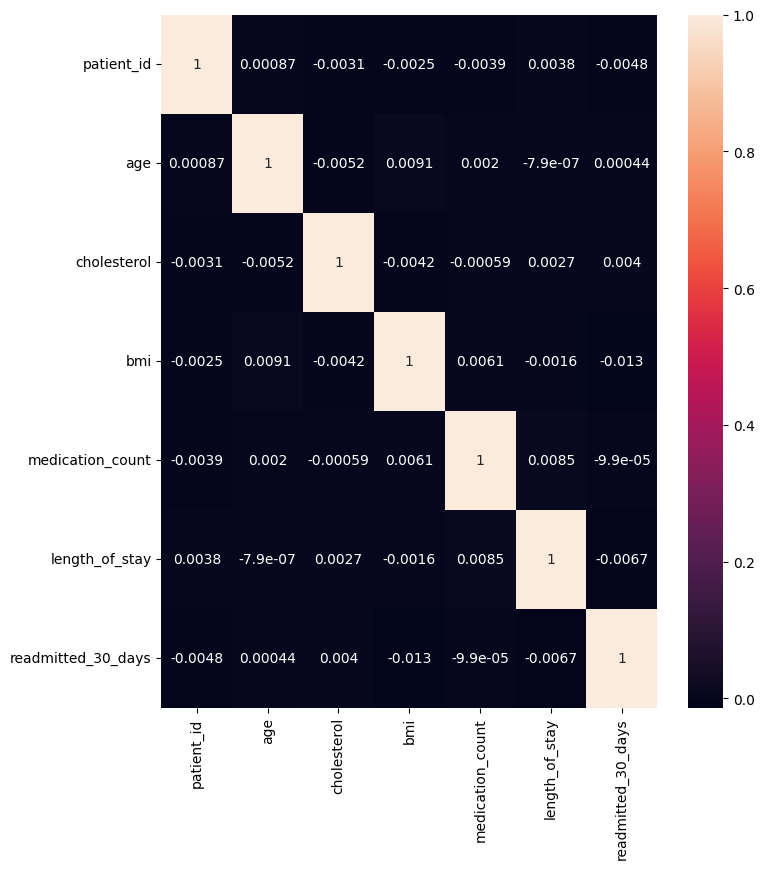

In [ ]:
plt.figure(figsize=(8,9))
sns.heatmap(df.corr(numeric_only=True),annot=True)


In [ ]:
df['gender'].value_counts()

,count
gender,
Male,10097
Other,10024
Female,9879


In [ ]:
df = pd.get_dummies(
    df,
    columns=["gender", "discharge_destination"],
    drop_first=True,
    dtype=int
)

In [ ]:
df.drop('patient_id',axis=1,inplace=True)

In [ ]:
df

,age,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab
0,74,130/72,240,31.5,Yes,No,5,1,1,0,1,1,0
1,46,120/92,292,36.3,No,No,4,3,0,0,0,1,0
2,89,135/78,153,30.3,No,Yes,1,1,0,0,1,0,0
3,84,123/80,153,31.5,No,Yes,3,10,0,0,0,0,0
4,32,135/84,205,18.4,No,Yes,6,4,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,112/80,157,31.4,No,No,4,10,1,1,0,0,0
29996,20,146/83,198,30.2,No,Yes,4,1,1,0,1,0,0
29997,40,131/96,275,23.3,Yes,Yes,7,2,0,0,1,0,0
29998,61,124/75,232,34.3,No,No,5,3,0,0,1,0,0


In [ ]:
bp = df["blood_pressure"].str.split("/", expand=True)

df["systolic_bp"] = pd.to_numeric(bp[0])
df["diastolic_bp"] = pd.to_numeric(bp[1])

df.drop("blood_pressure", axis=1, inplace=True)
df

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,74,240,31.5,Yes,No,5,1,1,0,1,1,0,130,72
1,46,292,36.3,No,No,4,3,0,0,0,1,0,120,92
2,89,153,30.3,No,Yes,1,1,0,0,1,0,0,135,78
3,84,153,31.5,No,Yes,3,10,0,0,0,0,0,123,80
4,32,205,18.4,No,Yes,6,4,0,0,1,1,0,135,84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,157,31.4,No,No,4,10,1,1,0,0,0,112,80
29996,20,198,30.2,No,Yes,4,1,1,0,1,0,0,146,83
29997,40,275,23.3,Yes,Yes,7,2,0,0,1,0,0,131,96
29998,61,232,34.3,No,No,5,3,0,0,1,0,0,124,75


In [ ]:
df['cholesterol'].value_counts()

,count
cholesterol,
191,234
253,228
207,228
172,227
164,226
...,...
187,169
245,168
174,166


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["cholesterol", "bmi", "systolic_bp", "diastolic_bp"]] = scaler.fit_transform(
    df[["cholesterol", "bmi", "systolic_bp", "diastolic_bp"]]
)

In [ ]:
df

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,74,0.338181,0.402284,Yes,No,5,1,1,0,1,1,0,-0.338645,-1.459778
1,46,1.531254,1.158416,No,No,4,3,0,0,0,1,0,-1.020252,0.781643
2,89,-1.657921,0.213251,No,Yes,1,1,0,0,1,0,0,0.002158,-0.787351
3,84,-1.657921,0.402284,No,Yes,3,10,0,0,0,0,0,-0.815770,-0.563209
4,32,-0.464849,-1.661326,No,Yes,6,4,0,0,1,1,0,0.002158,-0.114925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,-1.566146,0.386531,No,No,4,10,1,1,0,0,0,-1.565537,-0.563209
29996,20,-0.625455,0.197498,No,Yes,4,1,1,0,1,0,0,0.751926,-0.226996
29997,40,1.141211,-0.889442,Yes,Yes,7,2,0,0,1,0,0,-0.270484,1.229927
29998,61,0.154631,0.843361,No,No,5,3,0,0,1,0,0,-0.747609,-1.123564


In [ ]:
df['diabetes'].value_counts()

,count
diabetes,
No,15051
Yes,14949


In [ ]:
df['diabetes']=df['diabetes'].map({"Yes":1,"No":0})

In [ ]:
df['hypertension'].value_counts()

,count
hypertension,
No,15022
Yes,14978


In [ ]:
df['hypertension']=df['hypertension'].map({"Yes":1,"No":0})

In [ ]:
df

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,74,0.338181,0.402284,1,0,5,1,1,0,1,1,0,-0.338645,-1.459778
1,46,1.531254,1.158416,0,0,4,3,0,0,0,1,0,-1.020252,0.781643
2,89,-1.657921,0.213251,0,1,1,1,0,0,1,0,0,0.002158,-0.787351
3,84,-1.657921,0.402284,0,1,3,10,0,0,0,0,0,-0.815770,-0.563209
4,32,-0.464849,-1.661326,0,1,6,4,0,0,1,1,0,0.002158,-0.114925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,-1.566146,0.386531,0,0,4,10,1,1,0,0,0,-1.565537,-0.563209
29996,20,-0.625455,0.197498,0,1,4,1,1,0,1,0,0,0.751926,-0.226996
29997,40,1.141211,-0.889442,1,1,7,2,0,0,1,0,0,-0.270484,1.229927
29998,61,0.154631,0.843361,0,0,5,3,0,0,1,0,0,-0.747609,-1.123564


In [ ]:
df

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,74,0.338181,0.402284,1,0,5,1,1,0,1,1,0,-0.338645,-1.459778
1,46,1.531254,1.158416,0,0,4,3,0,0,0,1,0,-1.020252,0.781643
2,89,-1.657921,0.213251,0,1,1,1,0,0,1,0,0,0.002158,-0.787351
3,84,-1.657921,0.402284,0,1,3,10,0,0,0,0,0,-0.815770,-0.563209
4,32,-0.464849,-1.661326,0,1,6,4,0,0,1,1,0,0.002158,-0.114925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29,-1.566146,0.386531,0,0,4,10,1,1,0,0,0,-1.565537,-0.563209
29996,20,-0.625455,0.197498,0,1,4,1,1,0,1,0,0,0.751926,-0.226996
29997,40,1.141211,-0.889442,1,1,7,2,0,0,1,0,0,-0.270484,1.229927
29998,61,0.154631,0.843361,0,0,5,3,0,0,1,0,0,-0.747609,-1.123564


In [ ]:
scaler = StandardScaler()

df["age"] = scaler.fit_transform(df[["age"]])

In [ ]:
df

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,0.955340,0.338181,0.402284,1,0,5,1,1,0,1,1,0,-0.338645,-1.459778
1,-0.374439,1.531254,1.158416,0,0,4,3,0,0,0,1,0,-1.020252,0.781643
2,1.667721,-1.657921,0.213251,0,1,1,1,0,0,1,0,0,0.002158,-0.787351
3,1.430261,-1.657921,0.402284,0,1,3,10,0,0,0,0,0,-0.815770,-0.563209
4,-1.039328,-0.464849,-1.661326,0,1,6,4,0,0,1,1,0,0.002158,-0.114925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,-1.181804,-1.566146,0.386531,0,0,4,10,1,1,0,0,0,-1.565537,-0.563209
29996,-1.609233,-0.625455,0.197498,0,1,4,1,1,0,1,0,0,0.751926,-0.226996
29997,-0.659391,1.141211,-0.889442,1,1,7,2,0,0,1,0,0,-0.270484,1.229927
29998,0.337943,0.154631,0.843361,0,0,5,3,0,0,1,0,0,-0.747609,-1.123564


In [ ]:
data_cleaned=df

In [ ]:
data_cleaned

,age,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,readmitted_30_days,gender_Male,gender_Other,discharge_destination_Nursing_Facility,discharge_destination_Rehab,systolic_bp,diastolic_bp
0,0.955340,0.338181,0.402284,1,0,5,1,1,0,1,1,0,-0.338645,-1.459778
1,-0.374439,1.531254,1.158416,0,0,4,3,0,0,0,1,0,-1.020252,0.781643
2,1.667721,-1.657921,0.213251,0,1,1,1,0,0,1,0,0,0.002158,-0.787351
3,1.430261,-1.657921,0.402284,0,1,3,10,0,0,0,0,0,-0.815770,-0.563209
4,-1.039328,-0.464849,-1.661326,0,1,6,4,0,0,1,1,0,0.002158,-0.114925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,-1.181804,-1.566146,0.386531,0,0,4,10,1,1,0,0,0,-1.565537,-0.563209
29996,-1.609233,-0.625455,0.197498,0,1,4,1,1,0,1,0,0,0.751926,-0.226996
29997,-0.659391,1.141211,-0.889442,1,1,7,2,0,0,1,0,0,-0.270484,1.229927
29998,0.337943,0.154631,0.843361,0,0,5,3,0,0,1,0,0,-0.747609,-1.123564


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    max_iter=1000
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print("Accuracy:", accuracy_score(y_test, y_pred))
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8775
ROC-AUC: 0.5637849745786253

Confusion Matrix:
[[5265    0]
 [ 735    0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93      5265
           1       0.00      0.00      0.00       735

    accuracy                           0.88      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.77      0.88      0.82      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
